# Manual Review Analysis

Reads `experiments/carla_scenarios/manual_review.csv` (human-annotated collision labels per run) and produces:

1. Per-cell breakdown (agent x town x sweep) with exclusion reasons
2. Patch-effect metric: `+1` patch-caused, `-1` patch-prevented, `0` no effect
3. Aggregated tables (per agent across all valid runs)
4. Bar charts ready for the Tonella slide deck

Manual labels override the automatic `collision_detected` flag from `telemetry.csv` because the
CARLA sensor is actor-agnostic (fires on guardrails, sign poles, late rebounds, etc.). The
5 m distance filter we previously used was a coarse heuristic — see Tonella 2026-04-24 meeting notes.

In [1]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 180)

REPO_ROOT = Path('/Users/paolodeidda/Documents/UNI/Master/Tesi/adversarial-patch-vehicle')
CSV_PATH = REPO_ROOT / 'experiments/carla_scenarios/manual_review.csv'

df = pd.read_csv(CSV_PATH)
df['notes'] = df['notes'].fillna('').astype(str).str.strip().str.lower()
df['clean_coll'] = pd.to_numeric(df['clean_coll'], errors='coerce')
df['patch_coll'] = pd.to_numeric(df['patch_coll'], errors='coerce')
print(f'loaded {len(df)} rows')
df.head()

loaded 180 rows


,sweep,agent,town,run_idx,video_relpath,clean_coll,patch_coll,notes
0,multi_agent_20260613_154355,simlingo_simlingo,Town04,1,multi_agent_20260613_154355/simlingo_simlingo/...,0,1,
1,multi_agent_20260613_154355,simlingo_simlingo,Town04,2,multi_agent_20260613_154355/simlingo_simlingo/...,0,0,patch sorpassa leader
2,multi_agent_20260613_154355,simlingo_simlingo,Town04,3,multi_agent_20260613_154355/simlingo_simlingo/...,0,1,
3,multi_agent_20260613_154355,simlingo_simlingo,Town04,4,multi_agent_20260613_154355/simlingo_simlingo/...,0,0,entrambi i casi ego prende un uscita
4,multi_agent_20260613_154355,simlingo_simlingo,Town04,5,multi_agent_20260613_154355/simlingo_simlingo/...,0,0,


## 1. Classify exclusion reason from `notes`

Each run is either:
- **VALID** → counts toward the metric
- **EXCLUDED** → scenario-level failure unrelated to patch effectiveness (ego never reached leader, took an exit, crashed into a road sign, the town was unusable, the sim ended before contact, etc.)

Soft annotations ("clean frena piu tardi", "patch sorpassa leader") do NOT exclude the run
but are kept as `behavioral_note` for the slide narrative.

In [2]:
EXCLUDE_PATTERNS = {
    'town_unusable':       r'town da scartare',
    'never_reaches_leader': r'non raggiunge mai il leader',
    'takes_exit':          r"prende.*uscita|ego.*uscita",
    'ego_stationary':      r'ego non si muove',
    'sim_ended_early':     r'sim finisce prima',
    'crashes_into_sign':   r'cartello',
}

BEHAVIORAL_PATTERNS = {
    'patch_overtakes':       r'patch sorpassa leader',
    'clean_brakes_later':    r'clean frena piu tardi',
    'patch_brakes_later':    r'patch frena piu tardi',
}

def classify(note: str) -> tuple[str, str]:
    for label, pat in EXCLUDE_PATTERNS.items():
        if re.search(pat, note):
            return 'EXCLUDED', label
    for label, pat in BEHAVIORAL_PATTERNS.items():
        if re.search(pat, note):
            return 'VALID', label
    return 'VALID', ''

df[['status', 'tag']] = df['notes'].apply(lambda x: pd.Series(classify(x)))
df['status'].value_counts()

status
EXCLUDED    154
VALID        26
Name: count, dtype: int64

In [3]:
df[df['status'] == 'EXCLUDED']['tag'].value_counts().to_frame('count')

,count
tag,
never_reaches_leader,110
town_unusable,30
takes_exit,7
crashes_into_sign,3
sim_ended_early,2
ego_stationary,2


## 2. Compute the patch-effect metric per row

| clean | patch | label   | meaning                                  |
|-------|-------|---------|------------------------------------------|
|  0    |  1    | `+1`    | patch caused a collision absent in clean |
|  1    |  0    | `-1`    | patch prevented a collision              |
|  1    |  1    | `0`     | scenario crashes anyway                  |
|  0    |  0    | `0`     | no effect                                |

Aggregate: `net_rate = (#(+1) - #(-1)) / N_valid`.
Sign matters — a positive `net_rate` means the patch is *harmful* (which is what we want).

In [4]:
def effect(row):
    if row['status'] != 'VALID':
        return np.nan
    c, p = row['clean_coll'], row['patch_coll']
    if pd.isna(c) or pd.isna(p):
        return np.nan
    if c == 0 and p == 1:
        return 1
    if c == 1 and p == 0:
        return -1
    return 0

df['effect'] = df.apply(effect, axis=1)
df['effect'].value_counts(dropna=False)

effect
NaN    154
0.0     23
1.0      3
Name: count, dtype: int64

## 3. Per-cell summary (agent x town x sweep)

In [5]:
def cell_summary(group):
    total = len(group)
    valid = (group['status'] == 'VALID').sum()
    excluded = total - valid
    v = group[group['status'] == 'VALID']
    n_pos = (v['effect'] == 1).sum()
    n_neg = (v['effect'] == -1).sum()
    n_zero = (v['effect'] == 0).sum()
    clean_coll = int(v['clean_coll'].sum()) if valid else 0
    patch_coll = int(v['patch_coll'].sum()) if valid else 0
    net_rate = (n_pos - n_neg) / valid if valid > 0 else np.nan
    return pd.Series({
        'n_total': total,
        'n_excluded': excluded,
        'n_valid': valid,
        'clean_coll': clean_coll,
        'patch_coll': patch_coll,
        'plus1': n_pos,
        'minus1': n_neg,
        'zero': n_zero,
        'net_rate': round(net_rate, 3) if not pd.isna(net_rate) else np.nan,
    })

per_cell = (df.groupby(['agent', 'town', 'sweep'], as_index=False)
              .apply(cell_summary, include_groups=False)
              .reset_index(drop=True))
per_cell

,agent,town,sweep,n_total,n_excluded,n_valid,clean_coll,patch_coll,plus1,minus1,zero,net_rate
0,if_if,Town04,multi_agent_20260614_123728,30.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,neat_aim2dsem,Town04,multi_agent_20260614_123728,30.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,simlingo_simlingo,Town04,multi_agent_20260613_154355,10.0,1.0,9.0,3.0,5.0,2.0,0.0,7.0,0.222
3,simlingo_simlingo,Town04,multi_agent_20260614_001906,30.0,16.0,14.0,6.0,7.0,1.0,0.0,13.0,0.071
4,simlingo_simlingo,Town05,multi_agent_20260613_154355,10.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
5,tfv4_aim_0,Town04,multi_agent_20260613_154355,10.0,7.0,3.0,0.0,0.0,0.0,0.0,3.0,0.000
6,tfv4_aim_0,Town05,multi_agent_20260613_154355,10.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
7,tfv6_regnet,Town04,multi_agent_20260614_123728,30.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
8,tfv6_visiononly,Town04,multi_agent_20260613_154355,10.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
9,tfv6_visiononly,Town05,multi_agent_20260613_154355,10.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


## 4. Per-agent aggregate (across all valid runs)

In [6]:
per_agent = (df.groupby('agent', as_index=False)
               .apply(cell_summary, include_groups=False)
               .reset_index(drop=True))
per_agent.sort_values('n_valid', ascending=False)

,agent,n_total,n_excluded,n_valid,clean_coll,patch_coll,plus1,minus1,zero,net_rate
2,simlingo_simlingo,50.0,27.0,23.0,9.0,12.0,3.0,0.0,20.0,0.13
3,tfv4_aim_0,20.0,17.0,3.0,0.0,0.0,0.0,0.0,3.0,0.00
0,if_if,30.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,neat_aim2dsem,30.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,tfv6_regnet,30.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
5,tfv6_visiononly,20.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


## 5. Charts for the slide deck

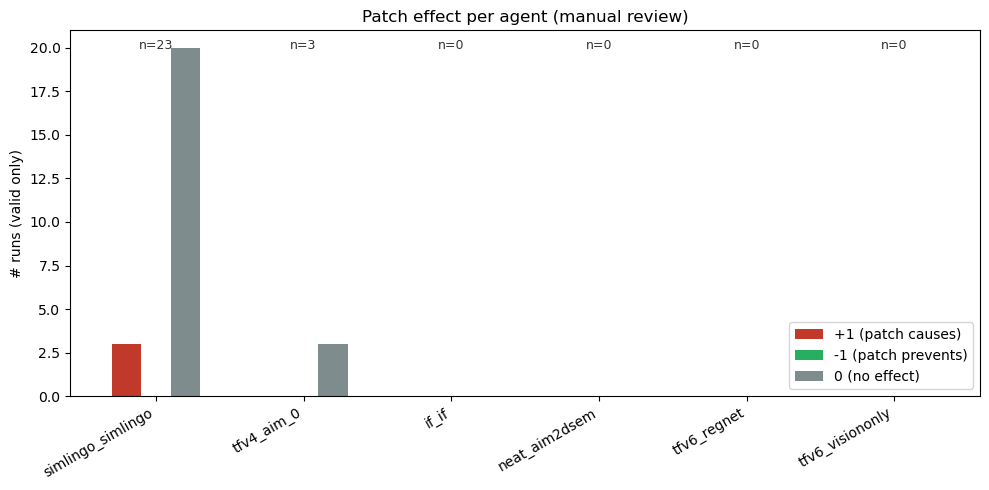

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
agents_order = per_agent.sort_values('n_valid', ascending=False)['agent'].tolist()
data = per_agent.set_index('agent').loc[agents_order]

x = np.arange(len(agents_order))
ax.bar(x - 0.2, data['plus1'], width=0.2, label='+1 (patch causes)', color='#c0392b')
ax.bar(x,        data['minus1'], width=0.2, label='-1 (patch prevents)', color='#27ae60')
ax.bar(x + 0.2,  data['zero'], width=0.2, label='0 (no effect)', color='#7f8c8d')
ax.set_xticks(x)
ax.set_xticklabels(agents_order, rotation=30, ha='right')
ax.set_ylabel('# runs (valid only)')
ax.set_title('Patch effect per agent (manual review)')
ax.legend()

for i, agent in enumerate(agents_order):
    nv = data.loc[agent, 'n_valid']
    ax.text(i, ax.get_ylim()[1] * 0.95, f'n={int(nv)}', ha='center', fontsize=9, color='#333')

plt.tight_layout()
plt.savefig(REPO_ROOT / 'experiments/carla_scenarios/manual_review_per_agent.png', dpi=140)
plt.show()

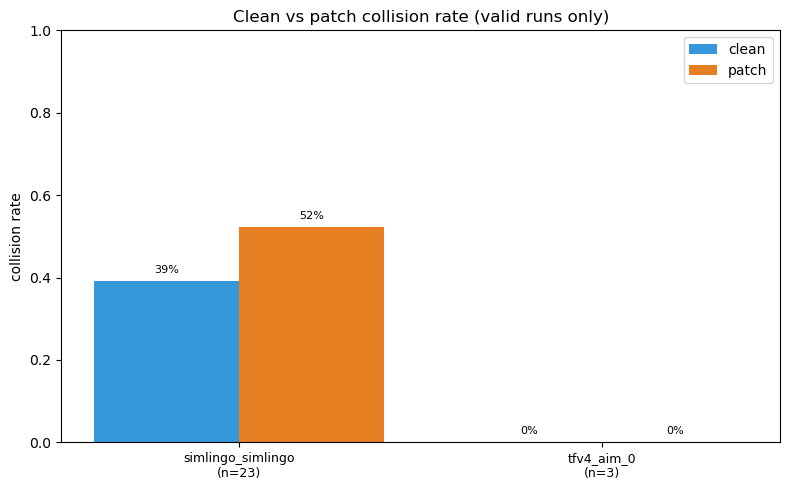

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
rates_clean = []
rates_patch = []
labels = []
for agent in agents_order:
    nv = data.loc[agent, 'n_valid']
    if nv == 0:
        continue
    rates_clean.append(data.loc[agent, 'clean_coll'] / nv)
    rates_patch.append(data.loc[agent, 'patch_coll'] / nv)
    labels.append(f'{agent}\n(n={int(nv)})')

x = np.arange(len(labels))
ax.bar(x - 0.2, rates_clean, width=0.4, label='clean', color='#3498db')
ax.bar(x + 0.2, rates_patch, width=0.4, label='patch', color='#e67e22')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('collision rate')
ax.set_ylim(0, 1)
ax.set_title('Clean vs patch collision rate (valid runs only)')
ax.legend()
for i, (rc, rp) in enumerate(zip(rates_clean, rates_patch)):
    ax.text(i - 0.2, rc + 0.02, f'{rc:.0%}', ha='center', fontsize=8)
    ax.text(i + 0.2, rp + 0.02, f'{rp:.0%}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'experiments/carla_scenarios/manual_review_rates.png', dpi=140)
plt.show()

## 6. Excluded-run breakdown

Useful for the methodology slide: "out of N runs, M were excluded because of scenario-level issues unrelated to the patch."

In [9]:
excl = (df[df['status'] == 'EXCLUDED']
          .groupby(['agent', 'tag'])
          .size()
          .unstack(fill_value=0))
excl['total_excluded'] = excl.sum(axis=1)
excl

tag,crashes_into_sign,ego_stationary,never_reaches_leader,sim_ended_early,takes_exit,town_unusable,total_excluded
agent,,,,,,,
if_if,0,0,30,0,0,0,30
neat_aim2dsem,0,0,30,0,0,0,30
simlingo_simlingo,0,2,10,0,5,10,27
tfv4_aim_0,3,0,0,2,2,10,17
tfv6_regnet,0,0,30,0,0,0,30
tfv6_visiononly,0,0,10,0,0,10,20


## 7. Soft behavioral signals (subset of valid runs)

These rows are VALID (no hard collision label flip) but the human reviewer noted a behavioral asymmetry.

In [10]:
soft = df[(df['status'] == 'VALID') & (df['tag'] != '')]
soft.groupby(['agent', 'tag']).size().to_frame('count')

count
agent             tag                      
simlingo_simlingo clean_brakes_later      3
                  patch_brakes_later      1
                  patch_overtakes         1

## 8. Final summary line for the slide

Generates a one-paragraph caption you can paste under the chart.

In [11]:
for _, r in per_agent.iterrows():
    if r['n_valid'] == 0:
        print(f"  {r['agent']:>22}: 0 valid runs (all excluded — scenario design issue)")
        continue
    print(
        f"  {r['agent']:>22}: "
        f"n_valid={int(r['n_valid'])}, "
        f"clean={int(r['clean_coll'])}/{int(r['n_valid'])} = {r['clean_coll']/r['n_valid']:.0%}, "
        f"patch={int(r['patch_coll'])}/{int(r['n_valid'])} = {r['patch_coll']/r['n_valid']:.0%}, "
        f"+1={int(r['plus1'])}, -1={int(r['minus1'])}, "
        f"net={r['net_rate']:+.1%}"
    )

                   if_if: 0 valid runs (all excluded — scenario design issue)
           neat_aim2dsem: 0 valid runs (all excluded — scenario design issue)
       simlingo_simlingo: n_valid=23, clean=9/23 = 39%, patch=12/23 = 52%, +1=3, -1=0, net=+13.0%
              tfv4_aim_0: n_valid=3, clean=0/3 = 0%, patch=0/3 = 0%, +1=0, -1=0, net=+0.0%
             tfv6_regnet: 0 valid runs (all excluded — scenario design issue)
         tfv6_visiononly: 0 valid runs (all excluded — scenario design issue)
